---
title: "Course Introduction"
---

In Block 1, you learned to make things happen with Python: work with data, write functions, and express decisions in code. Now imagine being asked to write a function that decides whether a message is spam. What would you put inside it?

Start by examining these messages and their labels. **What patterns might help you distinguish spam from non-spam?** Think of a rule you could express in Python before reading on.

| Message | Spam? |
|:--------|:-----:|
| 🎉 CONGRATULATIONS! YOU WON $1000! | Yes |
| Your package has shipped | No |
| Assignment due tomorrow | No |
| YOU WON A FREE PRIZE 🎁! | Yes |
| Dinner tonight? | No |
| Can we meet at 3 PM? | No |
| Are you free for lunch? | No |

Perhaps you noticed mentions of prizes or money, capital letters, or the word “free.” Let's try one simple rule: if a message contains “free,” label it as spam. The function below returns `True` for spam and `False` for not spam. Calling `.lower()` makes the check ignore capitalization.

**Before running the code or reading its output, predict the label it will assign to each message.** Where will the rule disagree with the table?


In [1]:
def is_spam(message):
    return "free" in message.lower()


messages = [
    "🎉 CONGRATULATIONS! YOU WON $1000!",
    "Your package has shipped",
    "Assignment due tomorrow",
    "YOU WON A FREE PRIZE 🎁!",
    "Dinner tonight?",
    "Can we meet at 3 PM?",
    "Are you free for lunch?",
]

for message in messages:
    label = "spam" if is_spam(message) else "not spam"
    print(f"{label}: {message}")


not spam: 🎉 CONGRATULATIONS! YOU WON $1000!
not spam: Your package has shipped
not spam: Assignment due tomorrow
spam: YOU WON A FREE PRIZE 🎁!
not spam: Dinner tonight?
not spam: Can we meet at 3 PM?
spam: Are you free for lunch?


::: {.callout-tip title="Pause and reflect"}

1. Which messages does the function label incorrectly? What is the consequence of each kind of mistake?
2. How would you change the rule? Can you invent a message that would break your revised rule?
3. How would you check whether your changes improved the detector overall, rather than just fixing these examples?

Try proposing a revised rule before reading on.
:::

::: {.callout-note collapse="true" title="Discussion"}

The lunch invitation is labelled as spam because it contains “free.” The “CONGRATULATIONS” message is labelled as spam in our table, but the function misses it because it does not contain that word. One mistake could hide a message we want to read; the other could let an unwanted message into our inbox.

Adding “won” might catch the missed spam message, but it would also flag “Our team won the game!” Capital letters and emoji are not reliable rules either: genuine messages can use both. We can keep adding exceptions, but it becomes difficult to anticipate all the ways people write messages.

To assess a revised rule, we would want a larger, varied collection of messages with known spam or non-spam labels, including messages we did not use to design the rule. Fixing these examples alone would not tell us how well the detector handles new messages.
:::

The Python code does exactly what we asked. The difficulty is choosing rules that work across many different messages.

**What if we used examples of spam and non-spam messages to learn useful patterns?**

In the Python function above, we supplied the rule ourselves. In **supervised machine learning**, we instead supply examples with known answers to a learning algorithm, which produces a **model**. We then use that model to predict answers for new inputs.

![Traditional programming uses inputs and explicit rules to produce outputs. Supervised machine learning uses training inputs and known outputs to learn a model, which then predicts outputs for new inputs.](img/traditional-programming-vs-ML.png)

There is still code in both approaches. What changes is whether we write the prediction rules ourselves or learn them from data. Learning from examples can help, but we will still need to check the predictions: a learned model can make both kinds of mistake too.


Welcome to DSCI 571: Supervised Learning I. If machine learning is new to you, you are in the right place. We will build from your programming experience, introducing the concepts and mathematical ideas as we need them. Your Python skills will help you put those ideas into practice; you do not need to arrive knowing how an ML model works.

Work through this chapter before the first lecture. It gives you a tour of the wider ML field before introducing our course's focus: supervised learning with scikit-learn. Pause at the examples and try making a prediction yourself. For now, aim to understand what a system learns from and what we want it to do. The details of the code will come later.

::: {.callout-lo}

## Learning outcomes {.unnumbered}

By the end of this chapter, you should be able to:

- Explain the relationship between artificial intelligence (AI), machine learning (ML), and deep learning (DL).
- Distinguish supervised, unsupervised, and reinforcement learning by the information available to the learner.
- Describe recommendation systems and generative AI, and explain why they can overlap with these learning approaches.
- Distinguish learning from examples from programming explicit rules, and judge when each approach is useful.
- Identify the inputs and target in a supervised learning problem, and distinguish predicting a category from predicting a number.
- Describe DSCI 571's focus on building and evaluating supervised learning workflows with scikit-learn.

:::


<br><br>

**Meet Eva, a fellow learner**

![](img/eva-hi.png)

Eva is a fictitious MDS student who has just finished Block 1. She can write Python functions and work with data, but she has never trained a machine learning model. When she hears that a model “learns,” she wonders: “What does that actually mean? Someone still has to write the code, right?”

She also wonders how she would check her spam detector. Testing a function against a few expected outputs feels familiar. But how could she test it against all the different messages people might send tomorrow?

We will return to Eva's questions throughout the book. Try answering them as you go, and keep track of your own questions too.


<br><br>

## What are AI, ML, and DL?

You may have encountered AI in a chatbot, a news story, or a discussion about technology. Before we go further, let's place machine learning within that bigger picture. These three terms are related, but they mean different things.

**Artificial intelligence (AI)** is a broad field concerned with building systems that perform tasks such as reasoning, recognizing images, understanding language, and making decisions. Some AI systems use rules written by people; others learn from data.

**Machine learning (ML)** is a part of AI in which systems learn patterns from data rather than having people explicitly write every rule for the task. For example, a spam filter can learn from messages that have been marked as spam or non-spam. People still write the learning software and choose the data and learning task.

**Deep learning (DL)** is a part of ML that uses neural networks with multiple layers to learn representations and patterns in data. It is used in many image, speech, and language systems. You do not need to know how neural networks work to follow this chapter.

![](img/ai-ml-dl.png)

These terms describe nested fields, not competing alternatives. Next, we will look at some problems that motivate learning from data, then use them to distinguish different kinds of ML.


<br><br><br><br>

## Why machine learning (ML)? [[video](https://www.youtube.com/watch?v=-1hTcS5ZE4w&t=1s)]

::: {.callout-tip title="See also"}
Check out [the accompanying video](https://www.youtube.com/watch?v=-1hTcS5ZE4w&t=1s) on this material. 
:::

### When is machine learning a useful approach?

Machine learning is especially useful when we have many examples and expect useful patterns in them, but the relationship is too complicated and noisy to express as a reliable set of hand-written rules. Image recognition, spam filtering, and personalized recommendations all have this character.

ML is not automatically the right tool for every problem:

- Use **explicit rules** when the logic is known, stable, and deterministic.
- Use **human judgment** when the task depends heavily on context, empathy, values, or accountability.
- Consider **machine learning** when useful rules are difficult to specify but representative data and a meaningful way to evaluate errors are available.

Real systems often combine all three. Before building a model, we should ask what role (if any) ML ought to play and what the consequences of its mistakes would be.

### From writing rules to learning patterns

For the spam detector, we could keep adding rules whenever we find a mistake. But each exception makes the program harder to maintain, and new messages may still slip through. An alternative is to collect examples and use a learning algorithm to find patterns that help distinguish spam from non-spam.

Before looking at an algorithm, try doing the pattern-finding yourself. In the next few examples, ask: **What information helps me decide, and what might make my guess wrong?**


### Learning patterns in images {.smaller}

Imagine that we want to write a program that can tell cats and foxes apart. What patterns might help?

![](img/cat-or-fox.png) 

| Image ID | Whiskers Present | Ear Size  | Face Shape | Fur Color  | Eye Shape   | Label |
|----------|------------------|-----------|------------|------------|-------------|-------|
| 1        | Yes              | Large     | Round      | Mixed      | Round       | Cat   |
| 2        | Yes              | Medium    | Round      | Brown      | Almond      | Cat   |
| 3        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |
| 4        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |
| 5        | Yes              | Small     | Round      | Mixed      | Round       | Cat   |
| 6        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |
| 7        | Yes              | Small     | Round      | Grey       | Round       | Cat   |
| 8        | Yes              | Small     | Round      | Black      | Round       | Cat   |
| 9        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |

Which patterns would you use to classify a new image?

In this small dataset, **fur colour, face shape, and eye shape seem informative**: the foxes have red fur, pointed faces, and narrow eyes, whereas the cats tend to have non-red fur and rounder faces and eyes. **Whiskers are not informative here** because every example has them; a feature that does not vary cannot help distinguish the two classes. Ear size may provide some information, but it does not separate the classes perfectly because some cats also have large ears.

These are patterns in the observed examples, not universal rules about all cats and foxes. More varied data could reveal exceptions or different useful patterns.

::: {.callout-note}
The table uses human-interpretable features to develop intuition. Modern image classifiers usually learn useful representations directly from pixel values.
:::

### Learning patterns in preferences

Imagine that you want to recommend a movie to Pat. Based on these examples, what would you recommend?

![](img/toy-movie-pattern.png)

What pattern connects Sam's and Pat's preferences? How confident are you in your recommendation?

Sam and Pat both rate *The Lion King*, *The Little Mermaid*, and *Bambi* highly, suggesting that their movie preferences may be similar. Because Sam also likes *Toy Story*, it could be a reasonable recommendation for Pat. This is the basic intuition behind **collaborative filtering**: interactions from people with similar preferences can help fill in a missing preference. Recommendation systems often combine this idea with information about the items or users, so they do not fit neatly into only one learning category.

Our confidence should be limited, however: the pattern is based on only a few overlapping ratings, and we know very little about the other factors that shape either person's preferences.

### Learning patterns without labels

Suppose we have a large collection of food photographs but no category labels. How might you organize these images into useful groups?

![](img/food-clustering-activity.png){fig-alt="A collage of many foods, including desserts, pasta, salads, soup, and breakfast dishes"}

A **clustering** method looks for groups of similar examples without being told the correct group for each image. To do this, we first need a numerical **representation** of each image, perhaps features learned by a neural network, and a way to describe which representations are similar. The method might then group foods by visual appearance, ingredients, cuisine, or some other pattern encoded by that representation. Unlike cat-versus-fox classification, there is no supplied target label and often no single correct grouping.

The resulting clusters do not explain themselves. People must examine and interpret them—and check whether the discovered grouping is useful or merely reflects incidental features such as plate colour, lighting, or background.

### One recurring idea

These systems all learn from examples:

- Image classifiers learn patterns in visual information.
- Recommenders learn patterns in preferences and interactions.
- Spam filters learn patterns in language.
- Clustering methods look for structure among examples that do not have labels.

The data and methods differ, but the goal is similar: **learn from observed examples and generalize to new cases.**

::: {.callout-caution}
A learned pattern is not necessarily meaningful or reliable. It may reflect accidents or biases in the training data.
:::

<br><br>

## Different kinds of machine learning

A spam detector is one small part of a much larger field. Here is a quick tour of five areas you may encounter. For now, aim to explain the main idea of each with an example; we will build the foundations in this course and explore more of the field in later ML courses.

### Supervised learning: predict an outcome

**Learn from examples with known answers.** Our spam detector learns from messages labelled spam or non-spam, then predicts a label for a new message. The answer can also be a number, such as a home's sale price.

![Labelled messages are used to learn how to predict whether a new message is spam.](img/ml-tour-supervised.svg){width="100%"}

### Unsupervised learning: find structure

**Look for patterns without supplied answer labels.** We might group the food photos we saw earlier by similarity, without telling the system which foods belong together. This is called **clustering**; we then examine whether the groups are useful.

![Mixed circles, triangles, and squares become groups of similar shapes, illustrating clustering.](img/ml-tour-unsupervised.svg){width="100%"}

### Reinforcement learning: learn through actions and rewards

**Learn how to act from feedback.** A robot in a simulation tries moving around a room and receives rewards for reaching its destination and penalties for collisions. It learns to choose actions that lead to more reward over time.

![A robot takes an action and receives a reward and a new situation, which inform future actions.](img/ml-tour-reinforcement.svg){width="100%"}

### Recommendation systems: suggest something relevant

**Use preferences and interactions to suggest items.** Recall Sam and Pat's movie ratings: their shared favourites give us a reason to recommend another movie Sam enjoyed to Pat. Music and shopping services face similar tasks.

![Sam and Pat both like movies A and B. Sam also likes C, so C is suggested to Pat.](img/ml-tour-recommendations.svg){width="100%"}

### Generative AI: produce content

**Use learned patterns to generate text, images, audio, or code.** For example, a language model can draft a study-group invitation from a short instruction, called a **prompt**. We still need to check whether the result is suitable and accurate.

![A prompt asking for a study-group invitation leads to a generated draft invitation.](img/ml-tour-generative.svg){width="100%"}

These areas overlap. Supervised, unsupervised, and reinforcement learning describe ways of learning; recommendations and generative AI describe what a system does and can draw on more than one learning approach.

::: {.callout-tip title="Explain it to a classmate"}

Choose one area and describe a use for it in one or two sentences. What would the system learn from, and what would you want it to do?
:::

You do not need to master all of these areas now. Our starting point is **supervised learning**: learning from known outcomes and checking how well we predict new ones.


## Our focus in DSCI 571


DSCI 571: Supervised Learning I builds the foundations for working with machine learning, with a focus on **supervised learning using scikit-learn** (imported in Python as `sklearn`). We will learn how to frame a prediction problem, prepare data, train models, and evaluate how well they work on new examples. Think of this as extending your Python toolkit: you will still write code and work with data, but you will also learn how to judge predictions that can be wrong even when the code runs correctly. Choosing and fitting an algorithm is only one part of that workflow.

This course is the starting point for the program's ML sequence. Later ML courses will cover **unsupervised learning, deep learning, and generative AI**, building on the foundations we develop here. The map below shows how DSCI 571 connects to courses on improving supervised learning workflows (DSCI 573), unsupervised learning (DSCI 563), deep learning (DSCI 572), and natural language processing (DSCI 575).

![Map of the MDS machine learning courses. DSCI 571 provides foundations for DSCI 573 and DSCI 563. DSCI 573 connects to DSCI 572, and both DSCI 572 and DSCI 563 connect to DSCI 575.](img/MDS-ML-map.png){width="100%"}

You do not need to understand every term in the map yet. For now, notice how the ability to build and evaluate a simple supervised learning workflow supports the work that follows. Across these courses, we will return to shared questions: What can the data tell us? How should we evaluate the result? What could go wrong when the system is used?

Chapter 0 provides this independent-study introduction before the eight lectures. The lecture chapters build a supervised learning workflow step by step.

| Chapter | Focus | Guiding question |
|---|---|---|
| **1** | Terminology, baselines, and decision trees | How do we turn data into a first prediction model? |
| **2** | Machine learning fundamentals | How can we estimate performance on new data? |
| **3** | Similarity-based models | When are nearby examples useful for prediction? |
| **4** | Preprocessing and pipelines | How do we prepare features without leaking information? |
| **5** | Column transformers and text features | How do we combine different kinds of inputs? |
| **6** | Hyperparameter optimization | How do we compare model settings systematically? |
| **7** | Linear models | How do weighted sums support regression and classification? |
| **8** | Loss functions, multiclass classification, and conclusions | What do models optimize, and how do we assess the complete workflow? |

The rest of this introduction previews supervised learning through three examples: detecting spam, classifying images with a pretrained model, and predicting housing prices. Focus on what each model receives and what it predicts; later chapters explain how to build and evaluate supervised learning workflows with scikit-learn. The image and housing demonstrations also use libraries beyond scikit-learn.


## Supervised machine learning

### Learning from inputs and known outcomes

Recall the spam example: each training message comes with a known outcome, spam or non-spam. These paired examples are our **training data**. The information we give the model is called the **input features**, commonly written as $X$, and the outcome we want to predict is the **target**, written as $y$. For text, we need to convert the messages into numerical features before the model can use them.

During **training**, also called **fitting**, a learning algorithm uses these pairs to construct a model that relates inputs to targets. We often write this model as a function $f$: it takes an input and produces a prediction. Once trained, the model can predict a target for a new example whose outcome we do not yet know.

![](img/sup-learning.png)

The aim is to make useful predictions on new examples, not merely to reproduce the training answers. We therefore keep some examples separate from training to help assess how well the model **generalizes** to unseen data.

Predicting a category, such as spam or non-spam, is called **classification**. Predicting a numerical value, such as a home's sale price, is called **regression**. Both are supervised learning tasks because the training examples include known targets.


### Example 1: Predict whether a message is spam or not 

#### Input features $X$ and target $y$

Let's return to the spam detector from the opening of the chapter. This time, we will give a learning algorithm examples instead of writing our own word-matching rules. We will train it using messages with known labels, then ask it to predict labels for messages kept separate from training. The dataset uses `ham` to mean non-spam.

You will recognize some Python ingredients below: imports, variables, and function calls. The unfamiliar names are tools we will learn to use throughout the course. `CountVectorizer` turns text into numerical word counts, `LogisticRegression` is a classification model, and `make_pipeline` connects the two steps. You do not need to memorize these names yet.

As you read, follow three steps: **set aside some messages, learn from the remaining examples, and predict labels for the messages we set aside.**


::: {.callout-note}
Download SMS Spam Collection Dataset from [here](https://www.kaggle.com/uciml/sms-spam-collection-dataset). 
:::

#### Training a supervised machine learning model with $X$ and $y$

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import HTML
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

pd.set_option("display.max_colwidth", 200)
DATA_DIR = Path("data")


In [3]:
sms_df = pd.read_csv(DATA_DIR / "spam.csv", encoding="latin-1")
sms_df = sms_df.drop(columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
sms_df = sms_df.rename(columns={"v1": "target", "v2": "sms"})
train_df, test_df = train_test_split(sms_df, test_size=0.10, random_state=42)
HTML(train_df.head().to_html(index=False))

target,sms
spam,"LookAtMe!: Thanks for your purchase of a video clip from LookAtMe!, you've been charged 35p. Think you can do better? Why not send a video in a MMSto 32323."
ham,"Aight, I'll hit you up when I get some cash"
ham,Don no da:)whats you plan?
ham,Going to take your babe out ?
ham,No need lar. Jus testing e phone card. Dunno network not gd i thk. Me waiting 4 my sis 2 finish bathing so i can bathe. Dun disturb u liao u cleaning ur room.


In [4]:
X_train, y_train = train_df["sms"], train_df["target"]
X_test, y_test = test_df["sms"], test_df["target"]
clf = make_pipeline(CountVectorizer(max_features=5000), LogisticRegression(max_iter=5000))
clf.fit(X_train, y_train);

#### Predicting on unseen data using the trained model

In [5]:
pd.DataFrame(X_test[0:4])

,sms
3245,"Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens"
944,"I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one m..."
1044,"We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p"
2484,Only if you promise your getting out as SOON as you can. And you'll text me in the morning to let me know you made it in ok.


In [6]:
pred_dict = {
    "sms": X_test[0:4],
    "spam_predictions": clf.predict(X_test[0:4]),
}
pred_df = pd.DataFrame(pred_dict)
pred_df.style.set_properties(**{"text-align": "left"})

,sms,spam_predictions
3245,"Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens",ham
944,"I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones",ham
1044,"We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p",spam
2484,Only if you promise your getting out as SOON as you can. And you'll text me in the morning to let me know you made it in ok.,ham


Before accepting these predictions, read the messages yourself. Do the predicted labels seem reasonable? Which message, if any, would you be least sure about?

To check the predictions, we need to compare them with the known targets. But even if all four are correct, that leaves Eva's question: how well would the detector work on tomorrow's messages? A few plausible predictions are a starting point, not enough evidence that the detector is reliable. Learning how to gather that evidence is a central part of this course.


<br><br>

### Example 2: Classify images with a pretrained model

What if the input is a photograph instead of a message? An image classifier takes pixel values as input and predicts a category. Before looking at the predictions, try describing each image yourself. Would you expect one label to capture everything in it?

Here we reuse a **pretrained model**: someone else has already trained it on labelled images. We do not call `fit` on our photographs. The helper function `classify_image` loads the model, prepares each image, and returns its highest-scoring categories. You do not need to understand those steps yet; deep learning will be covered in later courses.

::: {.callout-note title="Running the image example"}

This example uses PyTorch and torchvision. Its first run downloads the pretrained model, so the cell is not executed automatically when building the book. You can run it in the notebook with the project dependencies installed and internet access for the initial download.
:::


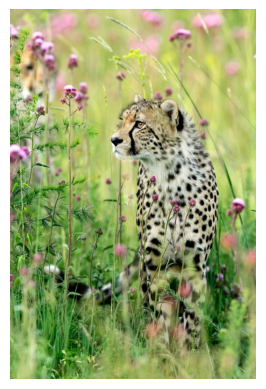

       Class  Probability score
     cheetah              0.973
     leopard              0.024
      jaguar              0.002
snow leopard              0.001
------------------------------------------------------------


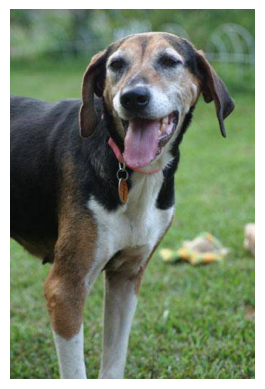

                     Class  Probability score
               EntleBucher              0.237
Greater Swiss Mountain dog              0.235
                    beagle              0.162
               Appenzeller              0.152
------------------------------------------------------------


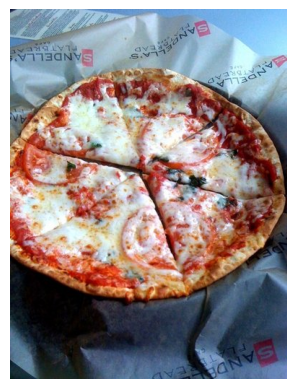

     Class  Probability score
     pizza              0.996
frying pan              0.002
    potpie              0.001
 meat loaf              0.000
------------------------------------------------------------


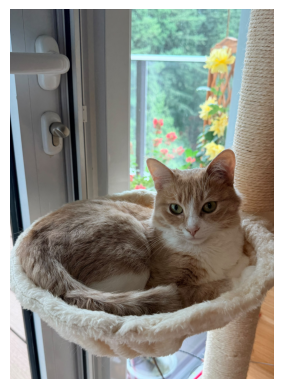

       Class  Probability score
   tiger cat              0.345
Egyptian cat              0.338
       tabby              0.060
   washbasin              0.047
------------------------------------------------------------


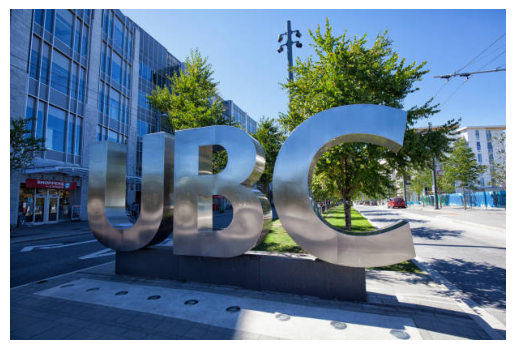

     Class  Probability score
car mirror              0.212
       tub              0.092
sunglasses              0.077
  fountain              0.076
------------------------------------------------------------


In [7]:
#| eval: false
import sys

import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(str(Path("code").resolve()))
from img_classify import classify_image

image_paths = sorted((DATA_DIR / "test_images").glob("*.*"))

for image_path in image_paths:
    with Image.open(image_path) as image:
        plt.imshow(image.convert("RGB"))
        plt.axis("off")
        plt.show()

    predictions = classify_image(image_path)
    print(predictions.to_string(index=False))
    print("-" * 60)


The output lists predicted categories and their probability scores. A high score does not guarantee a correct prediction. The model chooses among the categories it learned during training, which may not match how you would describe the photograph.

This is still a classification example even though we skipped training here: we are using a model that learned from labelled examples elsewhere.

### Example 3: Predict housing prices

A spam label or an image category is one of several possible categories. A home's sale price is a number, so predicting it is a **regression** task. Suppose we have records of past house sales, including attributes such as size and location. Can we use them to predict prices for other homes?

As in the spam example, we set aside some records before training. Here, the known answer for each training example is its sale price.


In [8]:
housing_df = pd.read_csv(DATA_DIR / "kc_house_data.csv")
housing_df = housing_df.drop(columns=["id", "date"])
housing_df = housing_df.rename(columns={"price": "target"})
housing_train, housing_test = train_test_split(
    housing_df, test_size=0.2, random_state=4
)
HTML(housing_train.head().to_html(index=False))


target,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
509000.0,2,1.50,1930,3521,2.0,0,0,3,8,1930,0,1989,0,98007,47.6092,-122.146,1840,3576
675000.0,5,2.75,2570,12906,2.0,0,0,3,8,2570,0,1987,0,98075,47.5814,-122.050,2580,12927
420000.0,3,1.00,1150,5120,1.0,0,0,4,6,800,350,1946,0,98116,47.5588,-122.392,1220,5120
680000.0,8,2.75,2530,4800,2.0,0,0,4,7,1390,1140,1901,0,98112,47.6241,-122.305,1540,4800
357823.0,3,1.50,1240,9196,1.0,0,0,3,8,1240,0,1968,0,98072,47.7562,-122.094,1690,10800


We give the model the home attributes as inputs and the sale prices as targets. This demonstration uses LightGBM, a library with a scikit-learn-style `fit` and `predict` interface. Focus on those two steps for now; understanding this particular algorithm is not a prerequisite for the course.


In [9]:
from lightgbm.sklearn import LGBMRegressor

X_housing_train = housing_train.drop(columns=["target"])
y_housing_train = housing_train["target"]
X_housing_test = housing_test.drop(columns=["target"])
y_housing_test = housing_test["target"]

housing_model = LGBMRegressor(random_state=123, verbose=-1, n_jobs=1)
housing_model.fit(X_housing_train, y_housing_train);


Now compare predictions with the actual prices for four homes kept out of training. Before looking at the results, would you expect the predicted prices to match the actual prices exactly?


In [10]:
housing_predictions = pd.DataFrame({
    "Predicted price": housing_model.predict(X_housing_test.iloc[:4]),
    "Actual price": y_housing_test.iloc[:4].to_numpy(),
})
housing_predictions.round(0)


,Predicted price,Actual price
0,345832.0,311100.0
1,601042.0,535000.0
2,311310.0,271000.0
3,597556.0,705000.0


A predicted price can be wrong by a little or a lot. That differs from checking whether a spam label is correct, so we will need ways to measure the size of prediction errors. Four homes only give us a glimpse; later we will evaluate predictions across a larger set of held-out examples.

Across all three examples, the model uses inputs to predict a target. The inputs can be text, images, or rows of home attributes; the target can be a category or a number. We can train a model ourselves or reuse one trained elsewhere, but in either case we need evidence that its predictions are useful for our task.


<br><br>

### Eva's questions

Eva can follow the broad steps of the spam example, but she still has questions:

- “What changes inside the model when we call `fit`?”
- “How can it classify a message it has never seen before?”
- “If my Python code runs without errors, how could my model still be poor?”
- “What happens if it sends an important message to the spam folder?”
- “How much evidence would convince me to use it on my own messages?”

You do not need to answer all of these yet. They give us a reason to study the methods and evaluation tools in the coming chapters. By the end of the course, you should be able to explain how you would investigate them.

![](img/eva-qm.png)


### Supervised machine learning workflow

In Python, getting a function to run is a milestone. You still need to check that it does what you intended. With machine learning, we also need to check whether a relationship learned from past examples is useful for new ones.

![](img/ml-workflow.png)

Throughout this course, we will revisit this workflow: frame the problem, examine the data, build and evaluate a model, study its limitations, and communicate the results. Each step helps us answer a practical question about whether we can use the predictions with confidence.


<br><br>

### Who or what should solve the problem?

Before choosing a model, ask whether the task is better suited to a human, an explicit set of rules, or a system that learns patterns from data.

| Best starting point | Example problems | Why? |
|---|---|---|
| **Human judgment** | Giving a student feedback on a personal essay; deciding how to support a patient after a difficult diagnosis; resolving an unusual dispute between two people | The task depends on context, empathy, values, or accountability. There may be no single correct answer. |
| **Rule-based system** | Checking whether an email address ends in `@student.ubc.ca`; calculating sales tax; rejecting a password shorter than 12 characters | The rules are known, stable, easy to state, and should be applied consistently. |
| **Machine learning system** | Filtering spam; predicting which songs a listener may enjoy; recognizing objects in photographs | Useful patterns exist in data, but writing complete and reliable rules by hand would be difficult. Some errors are expected. |

The boundary is not always sharp. A real system may combine all three: an ML model flags suspicious credit-card transactions, rules automatically block clearly impossible transactions, and a human reviews ambiguous or high-impact cases.

::: {.callout-important}
The fact that ML *can* make a prediction does not mean it should make the final decision. Consider the cost of errors, who is affected, and who should be accountable.
:::

### Try framing an ML problem

Think of a problem that might benefit from machine learning. Before choosing an algorithm, discuss these questions:

1. What would the inputs and desired outputs be?
2. How is the problem handled now? Are there useful human heuristics or explicit rules?
3. What data already exist, and what additional data could reasonably be collected?
4. What kinds of mistakes could the system make, and who would be affected?
5. Would ML support a person, automate part of the process, or make the final decision?

These questions connect model building to the real-world problem it is meant to address.

### ❓❓ Questions for you

### Exercise 0.1

**For each problem, what is the best starting point?**

- **H:** human judgment
- **R:** a rule-based system
- **M:** a machine learning system

Classify each problem as **H**, **R**, or **M**.

1. Checking whether a UBC email address ends with `@student.ubc.ca` before allowing login
2. Giving a student constructive feedback on a personal essay
3. Predicting which songs a listener might enjoy based on their listening history
4. Calculating the shipping fee from a published table of package weights and destinations
5. Recognizing which species of bird appears in a photograph
6. Resolving a disagreement between two project teammates after hearing both perspectives

::: {.callout-note collapse="true" title="Suggested answers"}

1. **R** — the condition is explicit and deterministic.
2. **H** — good feedback depends on meaning, goals, context, and care.
3. **M** — preferences involve complex patterns that can be learned from data.
4. **R** — the published table completely specifies the calculation.
5. **M** — visual categories are difficult to describe with exhaustive hand-written rules.
6. **H** — the task requires context, communication, and accountable judgment.

These are starting points, not universal answers. For example, ML might help retrieve relevant writing examples, but a person should remain responsible for personal feedback.
:::

## Summary

- **From rules to examples:** in ML, we use data to learn patterns rather than write every prediction rule ourselves.
- **Different tasks, different approaches:** supervised learning predicts known kinds of outcomes; unsupervised learning finds structure; reinforcement learning learns actions through rewards. Recommenders suggest items, and generative AI produces content.
- **Our starting point:** DSCI 571 builds supervised learning foundations with scikit-learn. Later courses explore more of the ML field.
- **Categories or numbers:** classification predicts a category, such as spam or non-spam; regression predicts a number, such as a house price.
- **Running code is not enough:** check predictions on examples the model did not learn from, and consider whether its mistakes are acceptable for the task.


![](img/eva-seeyou.png)